## Imports and Needed functions

In [ ]:
import numpy as np 
import math
import itertools
from itertools import product
import statistics as stats
import string
from scipy.stats import sem
import matplotlib.pyplot as plt
from matplotlib import rc

###########################################################
## Plate Reader data to dictionary data 

def PR_2_dicts(dataFile,numRows,numCols):
    ''' 
    Each data (text) file can have several measurement types, 
    so data for each measurement
    will be returned in its own dictionary. 
    Also, depending on which plate reader was used, the data
    files are formatted slightly differently. 
    So this code can handle both formats. 
    '''

    # generating the labels
    row_keys = list(string.ascii_uppercase[0:numRows])
    col_keys = range(1,numCols+1)

    cartprod = list(product(row_keys,col_keys))

    well_keys = []
    for i in cartprod:
        well_keys.append(str(i[0]+str(i[1])))

    dataRead = open(dataFile)

    count = 0
    
    ReadsLine = [] # get the line in which the number of reads appears. 
    
    TimeList = []  # where 'Time' appears in the data file is where data 
                   # starts (except the first appearance), and where 
                   # 'Results' appears is where the data ends. 
            
    for line in dataRead:
        if 'Reads' in line: 
            ReadsLine.append(line)
        if 'Time' in line:
            TimeList.append(count) 
        if 'Results' in line:
            TimeList.append(count) 
        count += 1

    Reads = [] # getting the number of reads
    for word in ReadsLine[0].split():
        if word.isdigit():
            Reads.append(int(word))

    dataFinal = []  
    
    # need to properly define where the different measurements start and end
    ''' Example: If you have a file that has contains the following 
        readouts (OD600, GFP, BFP, RFP) then we have 4 measurements. 
    ''' 
    for k in range(1,len(TimeList)-1):
        
        ''' If for some reason you only want 
            a subset of the measurements in the 
            data dictionary, then you can uncomment 
            and adjust the code below
        '''
        # if k > num_measurements: 
        #     break
        
        if k == (len(TimeList) - 2):
            dataStart = TimeList[k]
            dataEnd = TimeList[k+1] - 1
        else:
            dataStart = TimeList[k]
            dataEnd = TimeList[k+1] - 4

        dataRead = open(dataFile) 

        # creating a list of the data
        count = 0 
        data = []
        for line in dataRead:
            if count >= dataStart and count <= dataEnd:
                data.append(line)
            count += 1

        # formatting the data appropriately and replacing 'OVRFLW' by 100000.0
        for i in range(len(data)):
            data[i] = data[i].split('\t') # new element in each line after tab
            data[i][-1] = data[i][-1].strip() # get rid of '\n' at end of each line
            data[i] = data[i][2:] # don't want the time and temp elements
            data[i] = ' '.join(data[i]).split() # remove the empty strings 
            if 'OVRFLW' in data[i]:
                for series in range(0,len(data[i])): 
                    if data[i][series] == 'OVRFLW':
                        data[i][series] = 100000.0
            if 'Results' in data[i]:
                break
            

        # removing all empty lists
        data = [x for x in data if x != []]
        
        # convert to floats and removes the first list that contains all the well labels
        # Note : each row contains a snapshot for some time, 
        #        and each column contains the trajectory of a single variable
        data = np.array(data[1:], dtype=np.float64) 

        # assign the key-value pairs to a dictionary
        data_dict = {}
        for i in range(len(well_keys)):
            data_dict[well_keys[i]] = data[:,i:i+1]


        dataFinal.append(data_dict)
        
    ## Sanity check
    print('length of data_Final',len(dataFinal))
    print('length of dataFinal[0].keys()',len(dataFinal[0].keys()))
    print('shape of data', np.shape(data))
    
        
    return dataFinal,Reads[0]

#############################################################################
''' Data Analysis Functions'''
#############################################################################


''' min and max vectors through time for plate reader data
    - works off of the data arrays created by the function
      "create_data_arrays"
inputs:  data_array (num_time_pts by num_samples matrix)
        
outputs: min_data (num_time_pts by 0 vector)
         max_data (num_time_pts by 0 vector)
'''
def variability_min_max(data_array):
    
    num_time_pts, num_samples = np.shape(data_array)
    
    # initalize variability errorbars
    max_data = np.zeros((num_time_pts,))
    min_data = np.zeros((num_time_pts,))

    ## Compute variability (min and max) errorbars

    for i in range(num_time_pts):

        min_data[i] = min(data_array[i,:])
        max_data[i] = max(data_array[i,:])
            
                
    return min_data, max_data

###################################################################

''' Compute the mean, standard deviation, and standard error
    for multiple samples in time. 
    - works off of the data arrays created by the function
      "create_data_arrays"
inputs:  data_array (num_time_pts by num_samples matrix)
outputs: mean_vector (num_time_pts, 1 array)
         std_vector  (num_time_pts, 1 array)
         sem_vector  (num_time_pts, 1 array)
    Note: Every element of each output vector will be that 
    statistical measurement for that given point in time
'''

def get_stats(data_array):
    # compute sample stats in time

    # average at each time point
    mean_vector = np.zeros((num_time_pts, 1))

    # standard deviation at each time point
    std_vector = np.zeros((num_time_pts, 1))

    # standard error at each time point
    sem_vector = np.zeros((num_time_pts, 1))

    for i in range(num_time_pts):
        mean_vector[i] = stats.mean(data_array[i,:])
        std_vector[i] = np.std(data_array[i,:])
        sem_vector[i] = sem(data_array[i,:])


    mean_vector = np.reshape(mean_vector, (num_time_pts,))       
    std_vector =  np.reshape(std_vector, (num_time_pts,))  
    sem_vector =  np.reshape(sem_vector, (num_time_pts,))  
    
    return mean_vector, std_vector, sem_vector

###################################################################

''' Make data arrays from selected samples
    to be used for error bars and statistical analysis

inputs: num_time_pts     (integer)
        final_well_key   (string)
        GFP              (dictionary)
        od               (dictionary)
outputs: GFP_array       (num_time_pts by num_samples matrix)
         OD_array        (num_time_pts by num_samples matrix)
         GFP_on_OD_array (num_time_pts by num_samples matrix)
'''
def create_data_arrays(num_time_pts, final_well_key, readout, od):
    
    # initalize arrays
    readout_array = np.zeros((num_time_pts, 1))
    OD_array = np.zeros((num_time_pts, 1))
    readout_on_OD_array = np.zeros((num_time_pts, 1))
    temp = np.zeros((num_time_pts, 1))
    
    for each in od.keys():
        
        # appends columns to arrays
        readout_array = np.append(readout_array, readout[each], axis=1)
        OD_array = np.append(OD_array, od[each], axis=1)
        
        # initialize temp vector for GFP/OD
        temp = np.empty((num_time_pts, 1))
        
        for i in range(num_time_pts):
            temp[i] = readout[each][i] / (od[each][i] + 1.)
            
        # appends columns to array   
        readout_on_OD_array = np.append(readout_on_OD_array, temp, axis=1)
        
        if each == final_well_key:
            break
        
    # removes first columns of all zeros from arrays
    readout_array = readout_array[:, 1:]
    OD_array = OD_array[:,1:]
    readout_on_OD_array = readout_on_OD_array[:, 1:]
    
        
    return readout_array, OD_array, readout_on_OD_array

## USER INPUTS NEEDED - Load Data

In [71]:
''' Specify all of the following: 
    - datafile
    - numRows
    - numCols
    - sampling_rate
    
    Note: A 96 well-plate has 8 rows labelled A through H
          and 12 columns labelled 1 through 12. 
          You must know the plate reader set up to enter this info
          This info as well as the sampling rate can most likely be 
          gathered from the dataFile itself, so open it up and take
          a look if need be. 
'''

# Get data from files
dataFile = 'KC_PR_Experiment_iteration2.txt'
numRows = 8
numCols = 12
sampling_rate = 4 # minutes

data,numReads = PR_2_dicts(dataFile,numRows,numCols)
# data3,numReads = PR_2_dicts(dataFile3,numRows,numCols)



length of data_Final 4
length of dataFinal[0].keys() 96
shape of data (181, 74)


## OD

dict_keys(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B9', 'B10', 'B11', 'B12', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10', 'G11', 'G12', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12'])


Text(0, 0.5, 'OD')

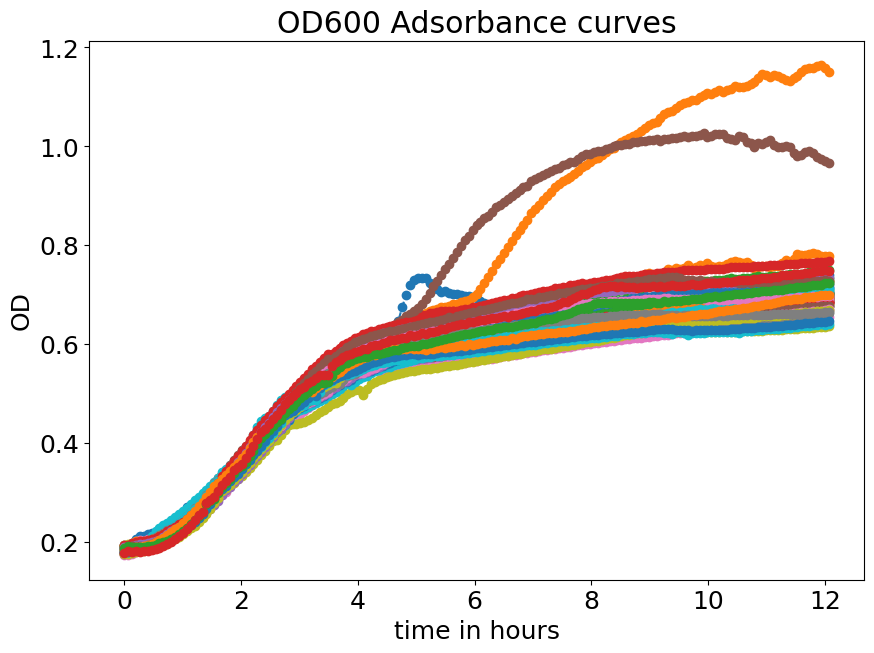

In [58]:
od = data[3]

GFP = data[2] 

BFP = data[1]

RFP = data[0] 

# ensures that the number of reades is equal to the number
# of reads actually obtained from plate reader
if od['A1'].shape[0] != numReads:
    numReads = od['A1'].shape[0]

# time vector represented in minutes
tSpan = np.linspace(0,numReads*sampling_rate,numReads)/60 

# Prints the keys because the keys maybe different from the wells which 
# actually contained samples in the plate reader experiment
print(od.keys())

# Plots OD600 curves
plt.rcParams.update({'font.size':18})
plt.figure(figsize=(10,7));
for each in od.keys():
    plt.plot(tSpan,od[each],'--o',ms=6);
plt.title(r'OD600 Adsorbance curves')
plt.xlabel('time in hours')
plt.ylabel('OD')




## OD-normalized GFP

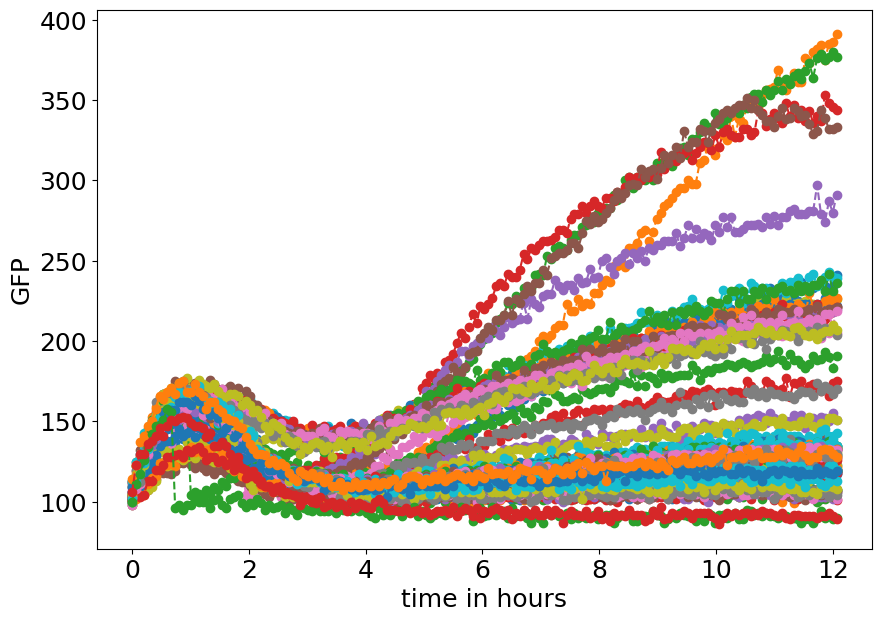

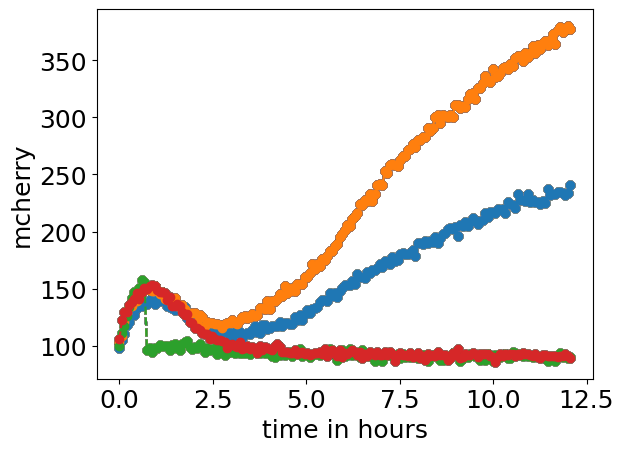

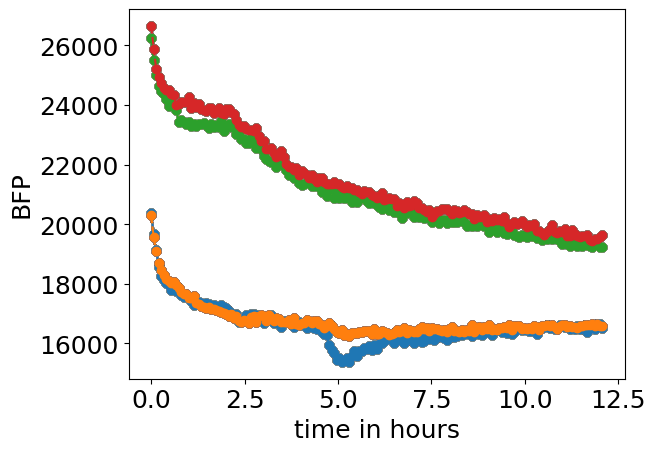

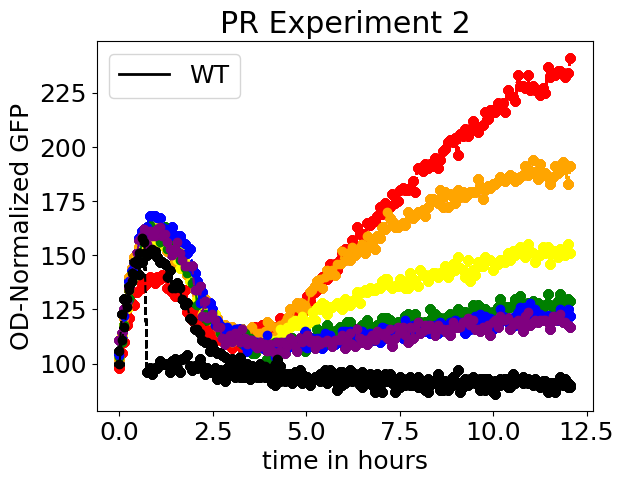

In [73]:
# ensures that the number of reades is equal to the number
# of reads actually obtained from plate reader
if GFP['A1'].shape[0] != numReads:
    numReads = GFP['A1'].shape[0]

# Plots GFP/OD 
plt.figure(figsize=(10,7));
for each in od.keys():
    plt.plot(tSpan,GFP[each],'--o',ms=6)
# plt.title(r'Dh5$\alpha$ with HPL plasmid')
plt.xlabel('time in hours')
plt.ylabel('GFP')




plt.figure()

GFP = data[0] 
for each in od.keys():
    plt.plot(tSpan,RFP['A1'],'--o',ms=6)
    plt.plot(tSpan,RFP['B1'],'--o',ms=6)
    plt.plot(tSpan,RFP['G1'],'--o',ms=6)
    plt.plot(tSpan,RFP['G2'],'--o',ms=6)

plt.xlabel('time in hours')
plt.ylabel('mcherry')

plt.figure()

for each in od.keys():
    plt.plot(tSpan,BFP['A1'],'--o',ms=6)
    plt.plot(tSpan,BFP['B1'],'--o',ms=6)
    plt.plot(tSpan,BFP['G1'],'--o',ms=6)
    plt.plot(tSpan,BFP['G2'],'--o',ms=6)

plt.xlabel('time in hours')
plt.ylabel('BFP')


plt.figure()
for each in od.keys():
    plt.plot(tSpan,GFP['A1'],'--o',ms=6, color='red')
    plt.plot(tSpan,GFP['A3'],'--o',ms=6, color='orange')
    plt.plot(tSpan,GFP['A5'],'--o',ms=6, color='yellow')
    plt.plot(tSpan,GFP['A7'],'--o',ms=6, color='green')
    plt.plot(tSpan,GFP['A9'],'--o',ms=6, color='blue')
    plt.plot(tSpan,GFP['A11'],'--o',ms=6, color='purple')
    plt.plot(tSpan,GFP['G1'],'--o',ms=6, color='black', label='Wildtypes')
    plt.plot(tSpan,GFP['G2'],'--o',ms=6, color='black')
plt.xlabel('time in hours')
plt.ylabel('OD-Normalized GFP')
plt.title('PR Experiment 2')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='black', lw=2, label='WT'),   # Black for WT
    ]

# Create the legend with custom elements
plt.legend(handles=legend_elements, loc="upper left")







Text(0, 0.5, 'GFP / OD 600')

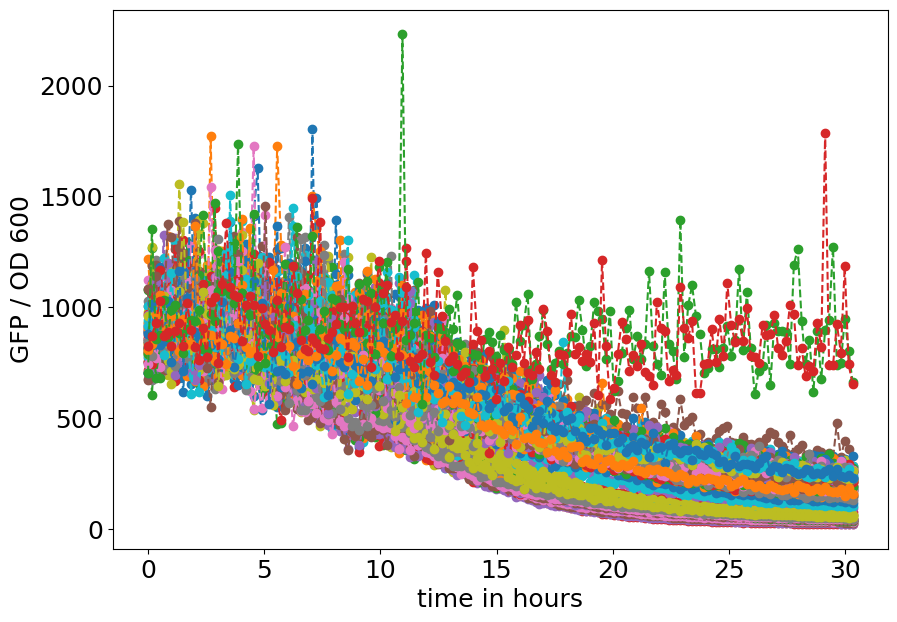

In [12]:
# ensures that the number of reades is equal to the number
# of reads actually obtained from plate reader
if GFP['A1'].shape[0] != numReads:
    numReads = GFP['A1'].shape[0]

# Plots GFP/OD 
plt.figure(figsize=(10,7));
for each in od.keys():
    plt.plot(tSpan,GFP[each]/(od[each] + 1.),'--o',ms=6); # with fudge factor
    # plt.plot(tSpan,GFP[each]/(od[each]),'--o',ms=6); # no fudge factor
# plt.title(r'Dh5$\alpha$ with HPL plasmid')
plt.xlabel('time in hours')
plt.ylabel('GFP / OD 600')

## Plot single sample

Text(0, 0.5, 'GFP / OD600')

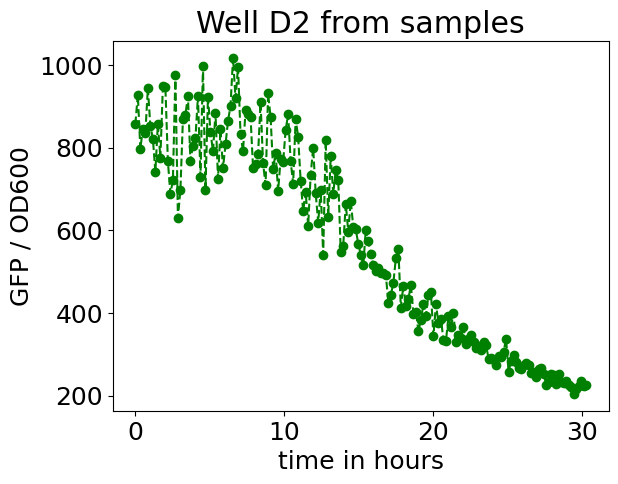

In [13]:
plt.plot(tSpan,GFP['D2']/(od['D2']+1),'--o', c = 'g', ms=6);
plt.title('Well D2 from samples')
plt.xlabel('time in hours')
plt.ylabel('GFP / OD600')

## Plot GFP and OD array

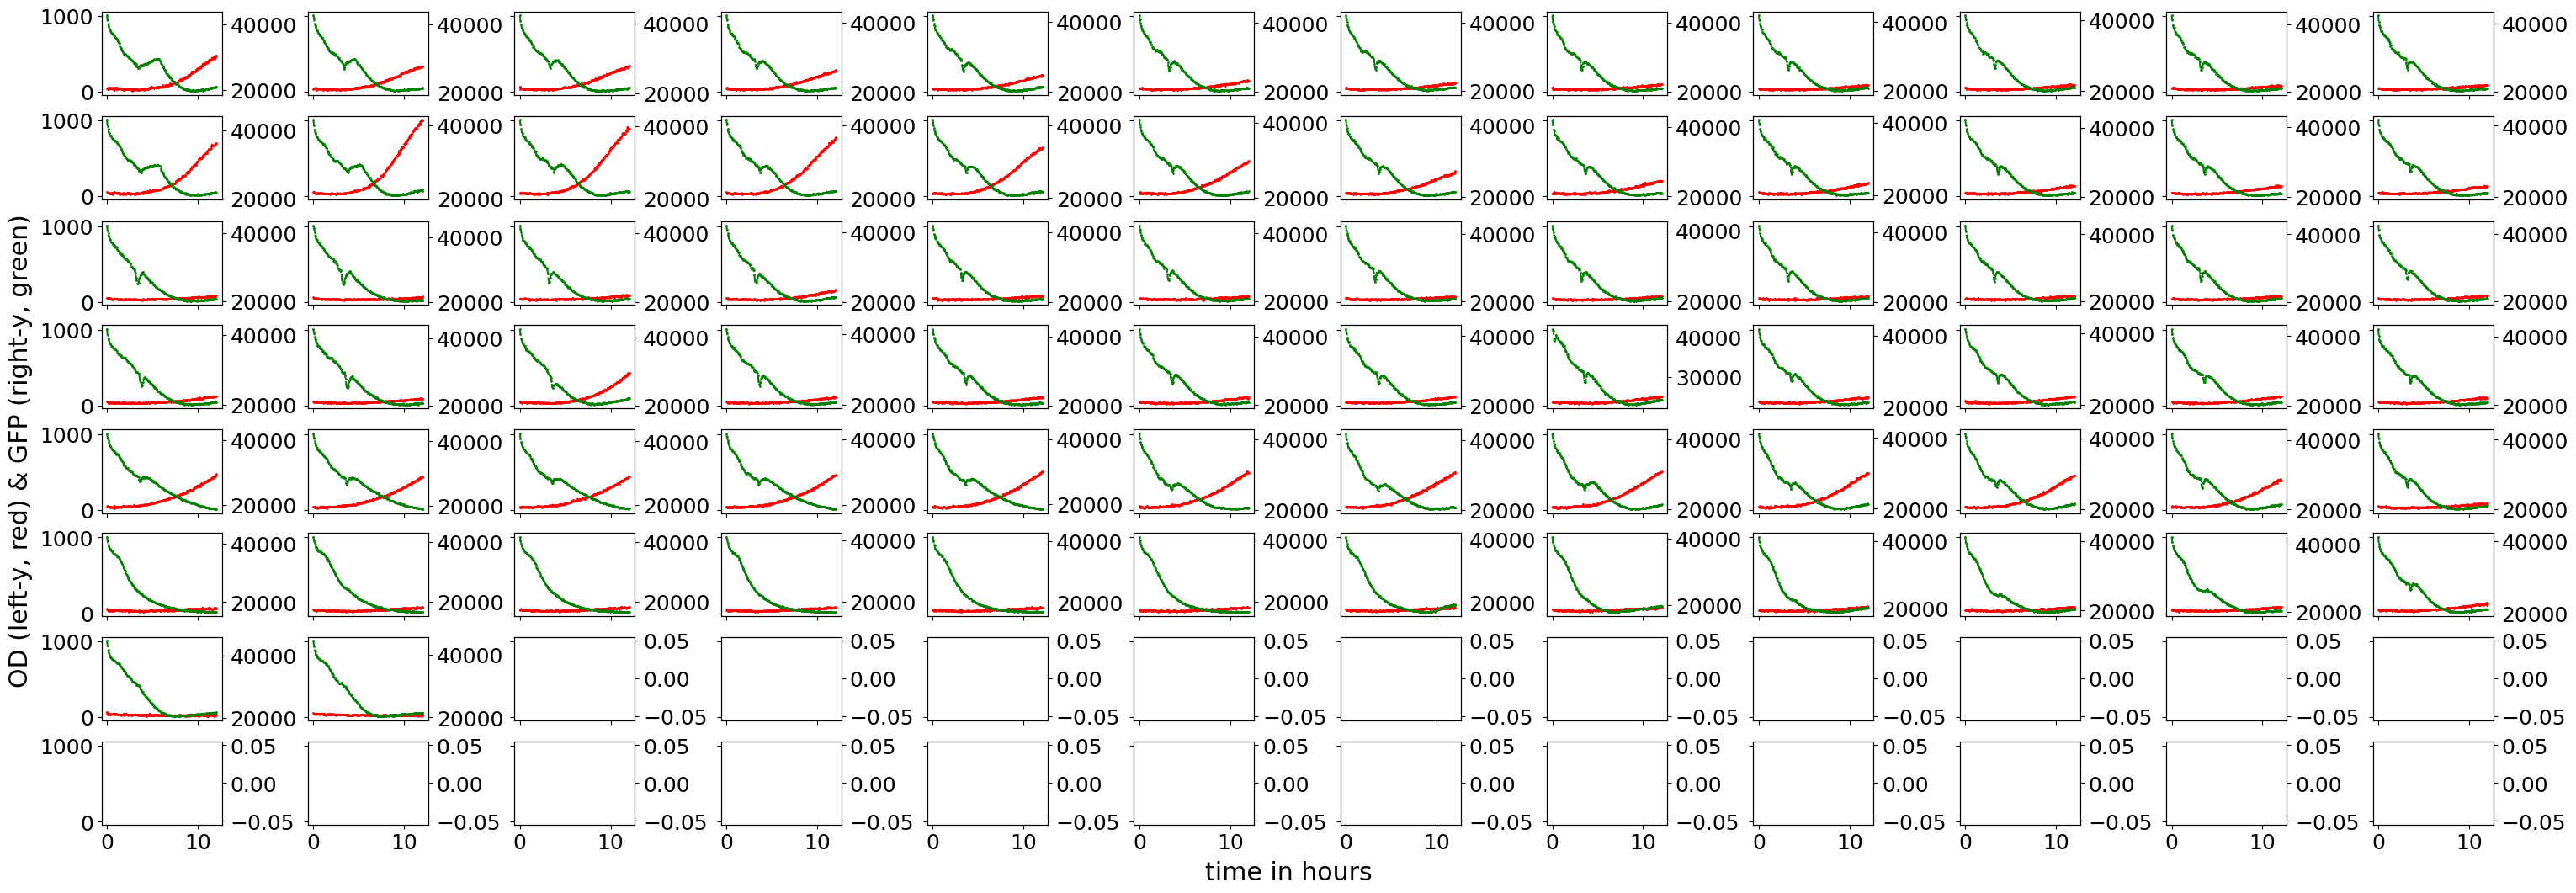

In [6]:

M = 0 # initialize subplot number

fig, ax1 = plt.subplots(numRows, numCols, sharex = True, sharey = True, constrained_layout = True)
fig.set_size_inches(30.5, 10.5)
# fig.suptitle("JH_AN_EY_DP_OS_HPL_PCA_Plate_5")
fig.supxlabel("time in hours")
# plt.ylim([0,1000])
fig.supylabel("OD (left-y, red) & GFP (right-y, green) ")

for each in od.keys():
    
    # the correct position in the subplot array is ensured by (math.floor(M/numCols), M%numCols) 
    
    # ax1 for OD vs time
    ax1[math.floor(M/numCols), M%numCols].plot(tSpan, od[each], '--o', ms=1, color='red');
    
    # ax1 and ax2 share the same x axis values (time)
    ax2 = ax1[math.floor(M/numCols), M%numCols].twinx()
    
    # ax2 for GFP vs time
    ax2.plot(tSpan, GFP[each], '--o', ms=1, color='green');
    
    M = M+1 # increase index of subplot number
    
    
## Scratch work
# M = 0
# fig, ax = plt.subplots(6, 10,sharex=True, sharey=True)
# for each in od.keys():
#     ax[math.floor(M/10), M%10].plot(tSpan,GFP[each],'--o',ms=1);
#     M = M+1
    


## Select Samples for statistical analysis

Text(0, 0.5, 'GFP/ OD600')

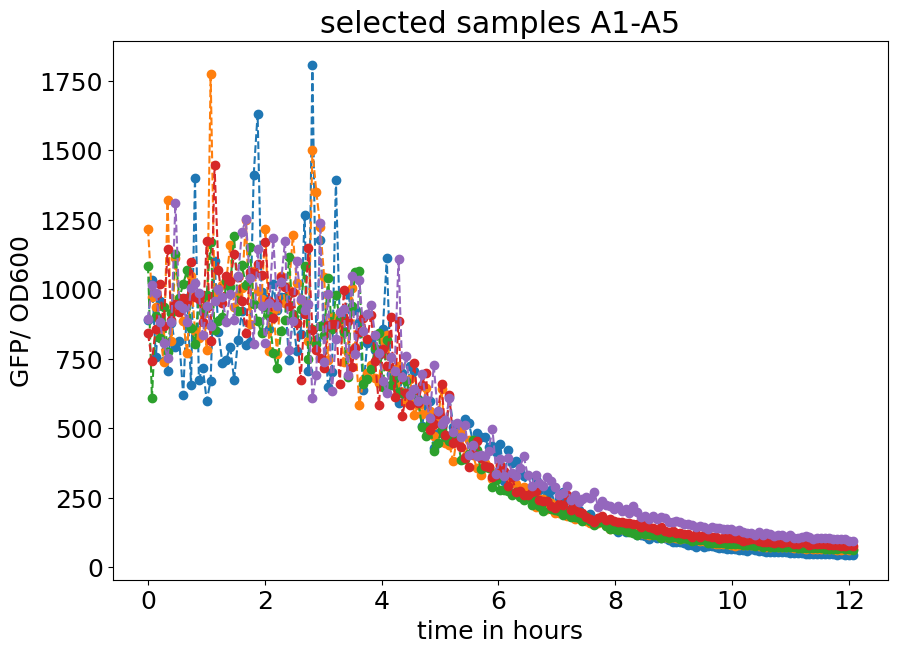

In [8]:
# Select  and plot samples
# To-Do: fully automate sample similarity detection with k-means

final_well_key = 'A5'

plt.figure(figsize=(10,7));

for each in od.keys():
        
    plt.plot(tSpan,GFP[each]/(od[each] + 1.),'--o',ms=6);
    
    if each == final_well_key:
        break
        
plt.title('selected samples A1-A5')
plt.xlabel('time in hours')
plt.ylabel('GFP/ OD600')



## Statistical Analysis

In [7]:
num_time_pts = numReads

GFP_array, OD_array, GFP_on_OD_array = create_data_arrays(num_time_pts, 
                                                          final_well_key, 
                                                          GFP, 
                                                          od)

min_GFP_on_OD, max_GFP_on_OD = variability_min_max(GFP_on_OD_array)

mean_GFP_on_OD, std_GFP_on_OD, sem_GFP_on_OD = get_stats(GFP_on_OD_array)

NameError: name 'final_well_key' is not defined

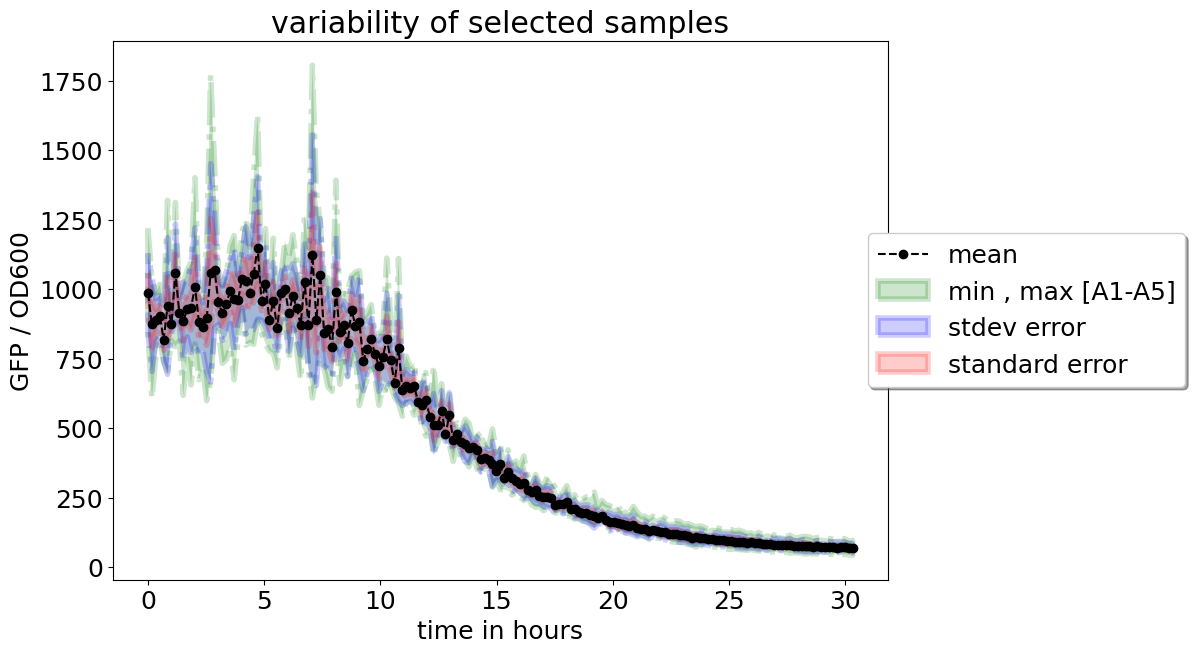

In [17]:
## Plot variability (min and max) errorbars
plt.figure(figsize=(10,7));
        
plt.plot(tSpan, mean_GFP_on_OD, '--o', c = 'k', ms=6, label = 'mean')

plt.fill_between(tSpan, min_GFP_on_OD, max_GFP_on_OD,
                alpha=0.2, edgecolor='g', facecolor='g',
                linewidth=4, linestyle='dashdot', 
                label = 'min , max [A1-A5]', antialiased=True)

plt.fill_between(tSpan, 
                 np.add(mean_GFP_on_OD, -std_GFP_on_OD), 
                 np.add(mean_GFP_on_OD, std_GFP_on_OD),
                 alpha=0.2, edgecolor='b', facecolor='b',
                 linewidth=4, linestyle='dashdot', label = 'stdev error', antialiased=True)

plt.fill_between(tSpan, 
                 np.add(mean_GFP_on_OD, -sem_GFP_on_OD), 
                 np.add(mean_GFP_on_OD, sem_GFP_on_OD),
                 alpha=0.2, edgecolor='r', facecolor='r',
                 linewidth=4, linestyle='dashdot', label = 'standard error', antialiased=True)

plt.title('variability of selected samples')
plt.xlabel('time in hours')
plt.ylabel('GFP / OD600')
plt.legend(loc='center right', bbox_to_anchor=(1.4, .5),
           ncol=1, fancybox=True, shadow=True)


## BFP

Text(0, 0.5, 'BFP')

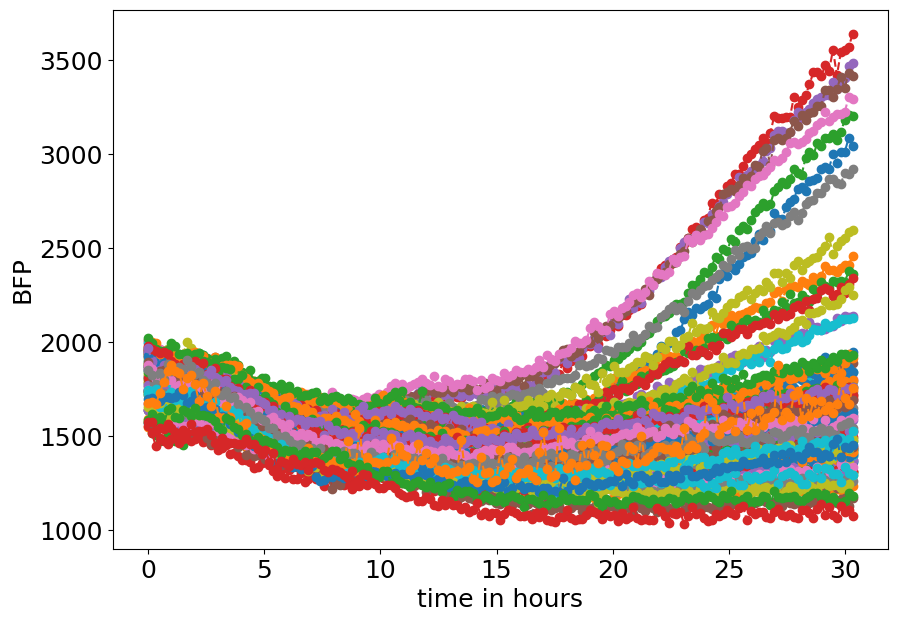

In [18]:
# ensures that the number of reades is equal to the number
# of reads actually obtained from plate reader
if BFP['A1'].shape[0] != numReads:
    numReads = BFP['A1'].shape[0]

# Plots GFP/OD 
plt.figure(figsize=(10,7));
for each in od.keys():
    plt.plot(tSpan,BFP[each],'--o',ms=6);
# plt.title(r'Dh5$\alpha$ with HPL plasmid')
plt.xlabel('time in hours')
plt.ylabel('BFP')

Text(0, 0.5, 'BFP / OD 600')

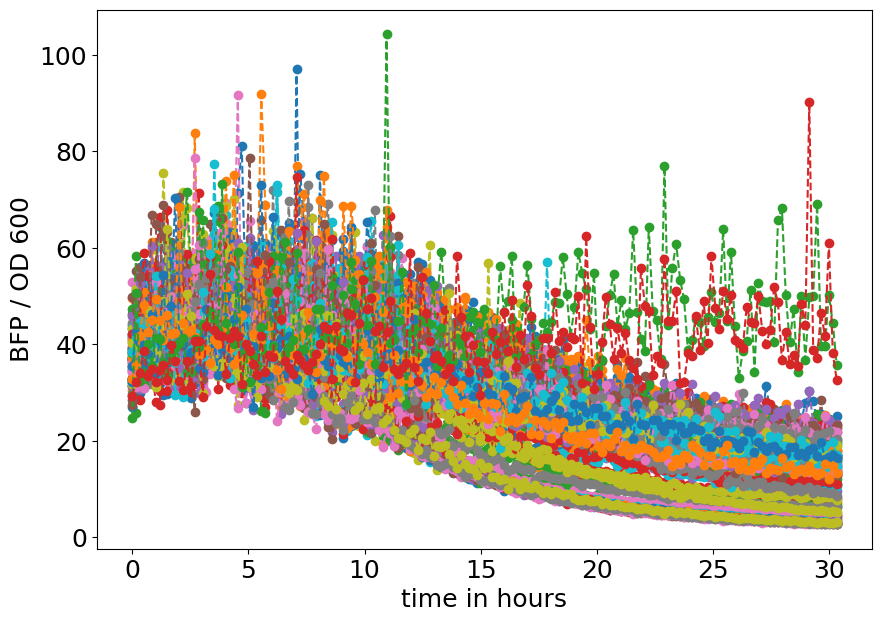

In [19]:
# ensures that the number of reades is equal to the number
# of reads actually obtained from plate reader
if BFP['A1'].shape[0] != numReads:
    numReads = BFP['A1'].shape[0]

# Plots GFP/OD 
plt.figure(figsize=(10,7));
for each in od.keys():
    plt.plot(tSpan, BFP[each]/(od[each] + 1.),'--o',ms=6);
# plt.title(r'Dh5$\alpha$ with HPL plasmid')
plt.xlabel('time in hours')
plt.ylabel('BFP / OD 600')

Text(0, 0.5, 'BFP / OD600')

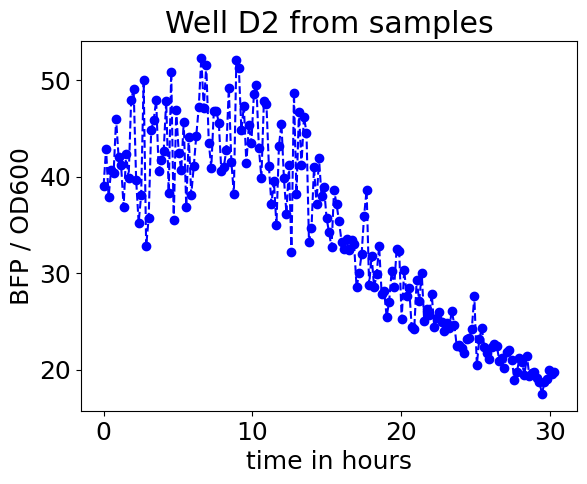

In [20]:
plt.plot(tSpan,BFP['D2']/(od['D2'] + 1.), '--o', c = 'b', ms=6);
plt.title('Well D2 from samples')
plt.xlabel('time in hours')
plt.ylabel('BFP / OD600')

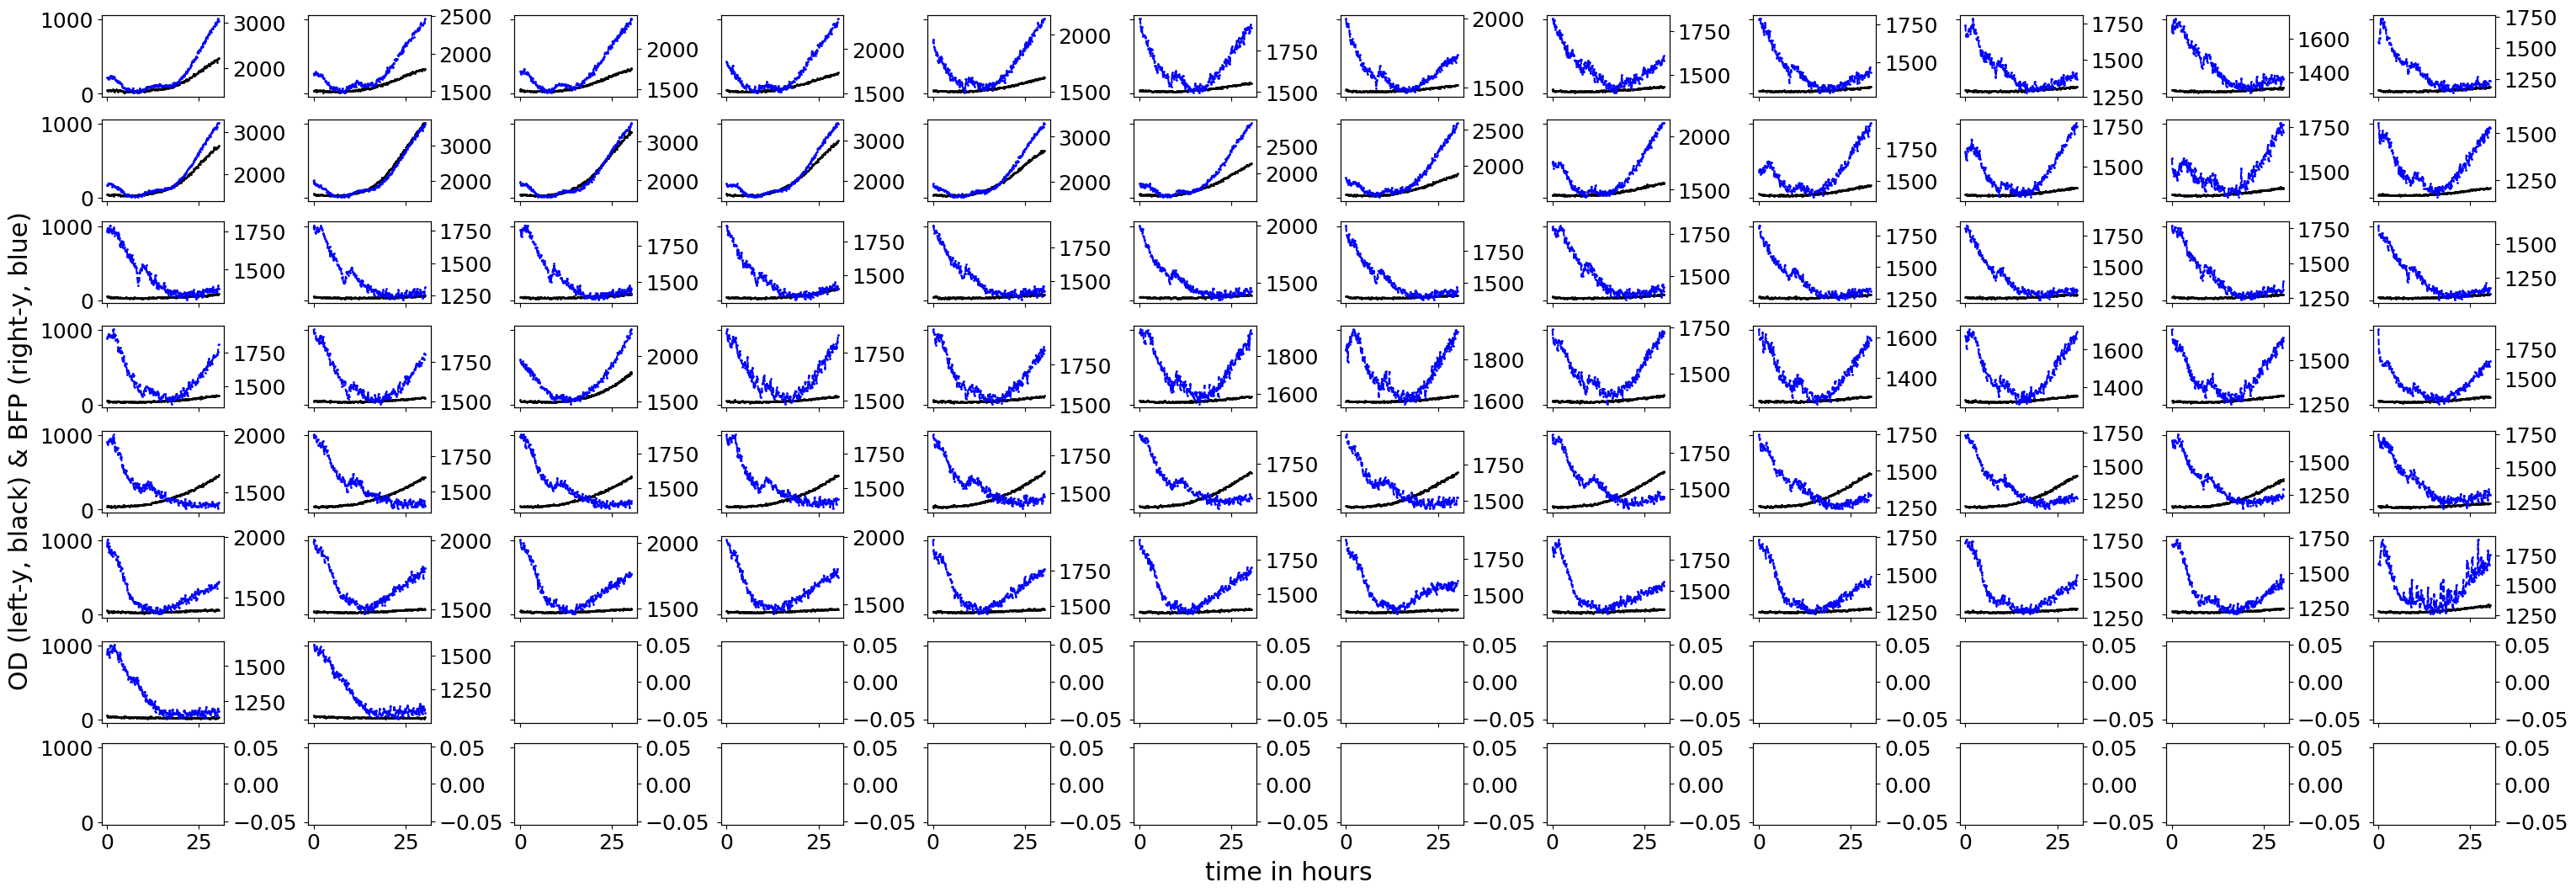

In [21]:
M = 0 # initialize subplot number

fig, ax1 = plt.subplots(numRows, numCols, sharex = True, sharey = True, constrained_layout = True)
fig.set_size_inches(30.5, 10.5)
# fig.suptitle("JH_AN_EY_DP_OS_HPL_PCA_Plate_5")
fig.supxlabel("time in hours")
# plt.ylim([0,1000])
fig.supylabel("OD (left-y, black) & BFP (right-y, blue) ")

for each in od.keys():
    
    # the correct position in the subplot array is ensured by (math.floor(M/numCols), M%numCols) 
    
    # ax1 for OD vs time
    ax1[math.floor(M/numCols), M%numCols].plot(tSpan, od[each], '--o', ms=1, color='black');
    
    # ax1 and ax2 share the same x axis values (time)
    
    ax2 = ax1[math.floor(M/numCols), M%numCols].twinx()
    
    # ax2 for GFP vs time
    ax2.plot(tSpan, BFP[each], '--o', ms=1, color='blue');
    
    M = M+1 # increase index of subplot number

Text(0, 0.5, 'BFP/ OD600')

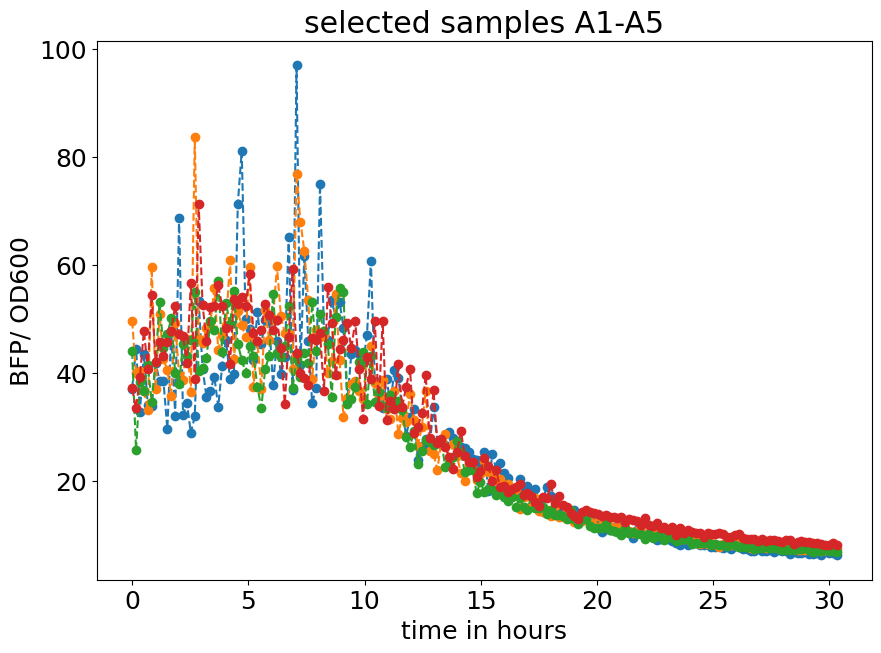

In [22]:
# Select  and plot samples
# To-Do: fully automate sample similarity detection with k-means

final_well_key = 'A5'

plt.figure(figsize=(10,7));

for each in od.keys():
    
    if each == final_well_key:
        break
        
    plt.plot(tSpan,BFP[each]/(od[each] + 1.),'--o',ms=6);
        
plt.title('selected samples A1-A5')
plt.xlabel('time in hours')
plt.ylabel('BFP/ OD600')

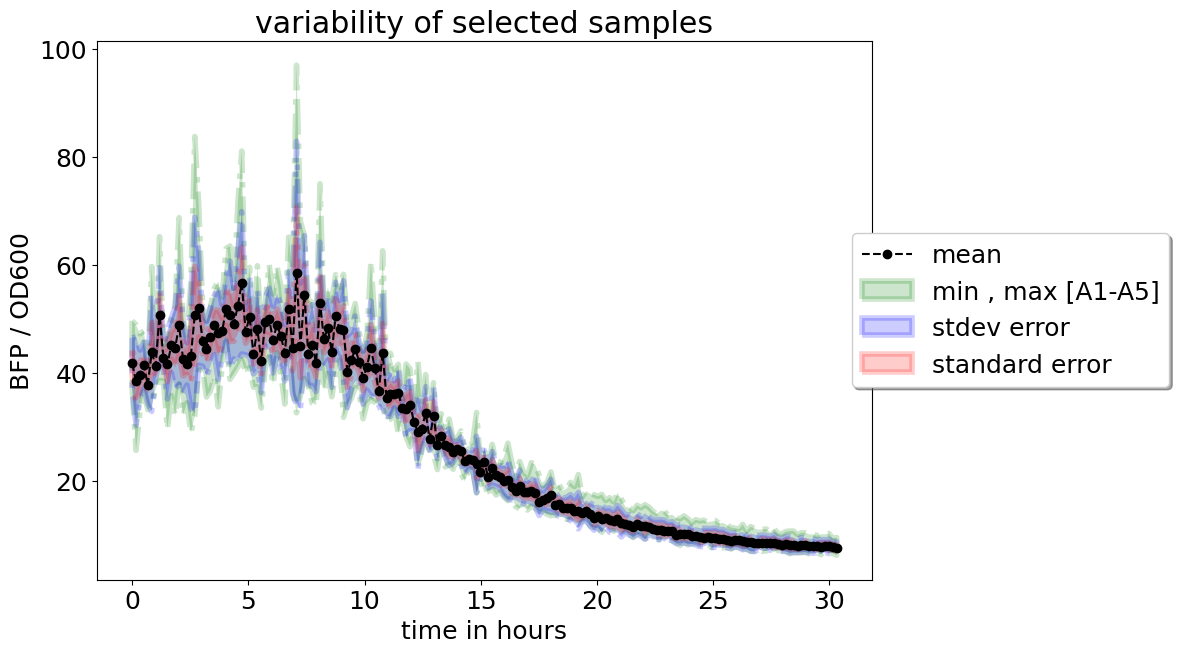

In [23]:
num_time_pts = numReads

BFP_array, OD_array, BFP_on_OD_array = create_data_arrays(num_time_pts, 
                                                          final_well_key, 
                                                          BFP, 
                                                          od)

min_BFP_on_OD, max_BFP_on_OD = variability_min_max(BFP_on_OD_array)

mean_BFP_on_OD, std_BFP_on_OD, sem_BFP_on_OD = get_stats(BFP_on_OD_array)

## Plot variability (min and max) errorbars
plt.figure(figsize=(10,7));
        
plt.plot(tSpan, mean_BFP_on_OD, '--o', c = 'k', ms=6, label = 'mean')

plt.fill_between(tSpan, min_BFP_on_OD, max_BFP_on_OD,
                alpha=0.2, edgecolor='g', facecolor='g',
                linewidth=4, linestyle='dashdot', 
                label = 'min , max [A1-A5]', antialiased=True)

plt.fill_between(tSpan, 
                 np.add(mean_BFP_on_OD, -std_BFP_on_OD), 
                 np.add(mean_BFP_on_OD, std_BFP_on_OD),
                 alpha=0.2, edgecolor='b', facecolor='b',
                 linewidth=4, linestyle='dashdot', label = 'stdev error', antialiased=True)

plt.fill_between(tSpan, 
                 np.add(mean_BFP_on_OD, -sem_BFP_on_OD), 
                 np.add(mean_BFP_on_OD, sem_BFP_on_OD),
                 alpha=0.2, edgecolor='r', facecolor='r',
                 linewidth=4, linestyle='dashdot', label = 'standard error', antialiased=True)

plt.title('variability of selected samples')
plt.xlabel('time in hours')
plt.ylabel('BFP / OD600')
plt.legend(loc='center right', bbox_to_anchor=(1.4, .5),
           ncol=1, fancybox=True, shadow=True)

## RFP

Text(0, 0.5, 'RFP')

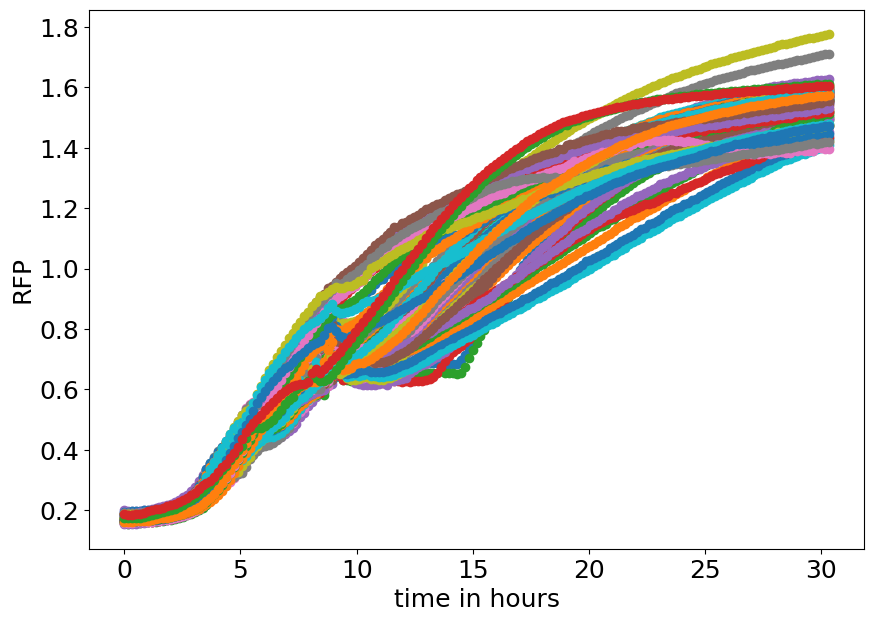

In [24]:
# ensures that the number of reades is equal to the number
# of reads actually obtained from plate reader
if RFP['A1'].shape[0] != numReads:
    numReads = RFP['A1'].shape[0]

# Plots GFP/OD 
plt.figure(figsize=(10,7));
for each in od.keys():
    plt.plot(tSpan,RFP[each],'--o',ms=6);
# plt.title(r'Dh5$\alpha$ with HPL plasmid')
plt.xlabel('time in hours')
plt.ylabel('RFP')

Text(0, 0.5, 'RFP / OD 600')

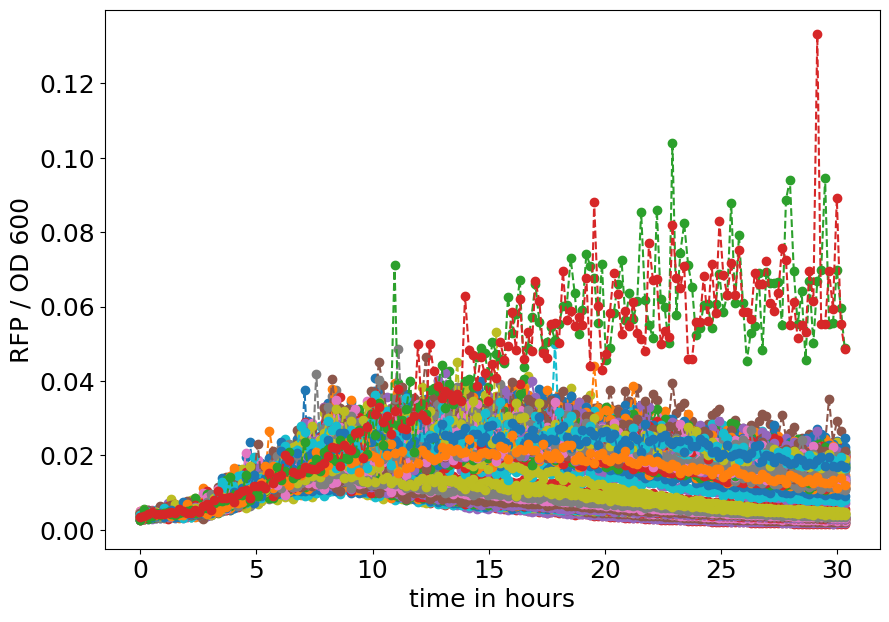

In [25]:
# ensures that the number of reades is equal to the number
# of reads actually obtained from plate reader
if RFP['A1'].shape[0] != numReads:
    numReads = RFP['A1'].shape[0]

# Plots GFP/OD 
plt.figure(figsize=(10,7));
for each in od.keys():
    plt.plot(tSpan,RFP[each]/(od[each] + 1.),'--o',ms=6);
# plt.title(r'Dh5$\alpha$ with HPL plasmid')
plt.xlabel('time in hours')
plt.ylabel('RFP / OD 600')

Text(0, 0.5, 'RFP / OD600')

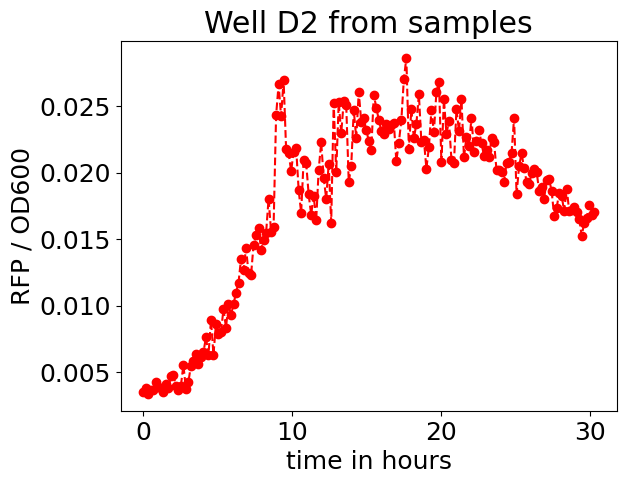

In [26]:
plt.plot(tSpan,RFP['D2']/(od['D2'] + 1.),'--o', c = 'r', ms=6);
plt.title('Well D2 from samples')
plt.xlabel('time in hours')
plt.ylabel('RFP / OD600')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

KeyboardInterrupt: 

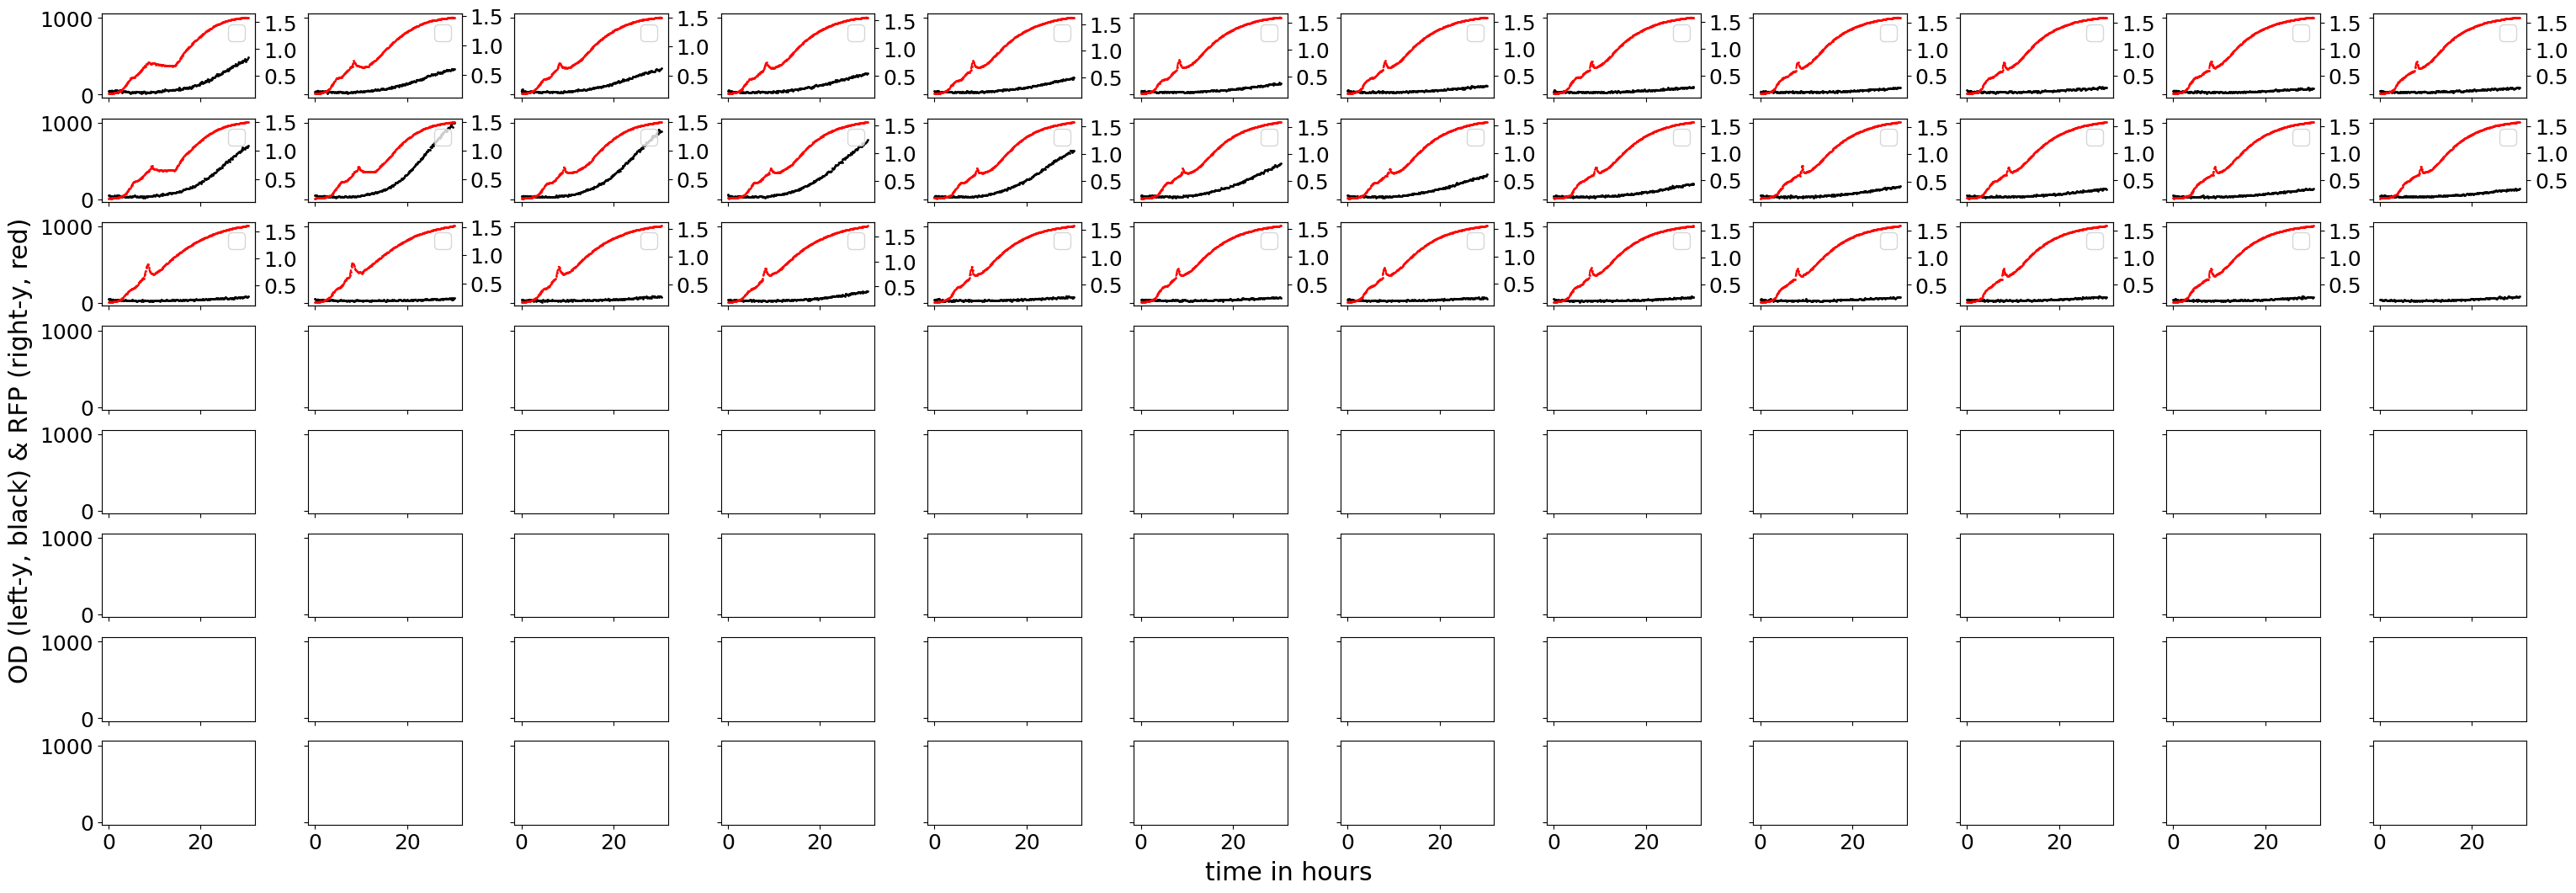

In [30]:
M = 0 # initialize subplot number

fig, ax1 = plt.subplots(numRows, numCols, sharex = True, sharey = True, constrained_layout = True)
fig.set_size_inches(30.5, 10.5)
# fig.suptitle("JH_AN_EY_DP_OS_HPL_PCA_Plate_5")
fig.supxlabel("time in hours")
# plt.ylim([0,1000])
fig.supylabel("OD (left-y, black) & RFP (right-y, red) ")

for each in od.keys():
    
    # the correct position in the subplot array is ensured by (math.floor(M/numCols), M%numCols) 
    
    # ax1 for OD vs time
    ax1[math.floor(M/numCols), M%numCols].plot(tSpan, od[each], '--o', ms=1, color='black');
    
    # ax1 and ax2 share the same x axis values (time)
    ax2 = ax1[math.floor(M/numCols), M%numCols].twinx()
    
    # ax2 for GFP vs time
    ax2.plot(tSpan, RFP[each], '--o', ms=1, color='red');
    plt.legend()
    
    M = M+1 # increase index of subplot number

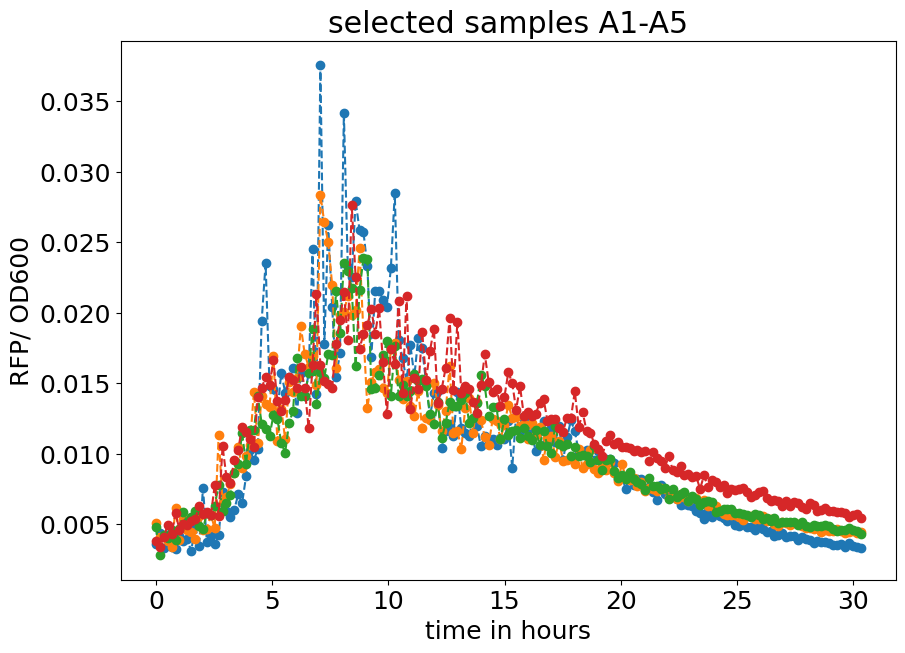

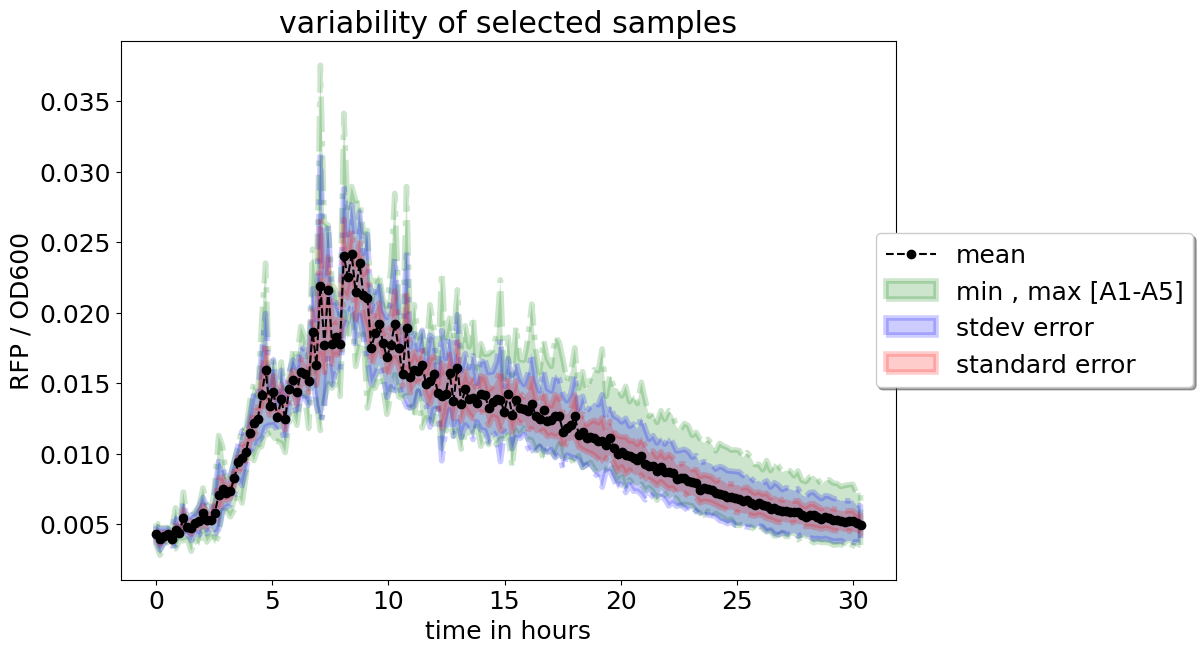

In [28]:
# Select  and plot samples
# To-Do: fully automate sample similarity detection with k-means

final_well_key = 'A5'

plt.figure(figsize=(10,7));

for each in od.keys():
    
    if each == final_well_key:
        break
        
    plt.plot(tSpan,RFP[each]/(od[each] + 1.),'--o',ms=6);
        
plt.title('selected samples A1-A5')
plt.xlabel('time in hours')
plt.ylabel('RFP/ OD600')

num_time_pts = numReads

RFP_array, OD_array, RFP_on_OD_array = create_data_arrays(num_time_pts, 
                                                          final_well_key, 
                                                          RFP, 
                                                          od)

min_RFP_on_OD, max_RFP_on_OD = variability_min_max(RFP_on_OD_array)

mean_RFP_on_OD, std_RFP_on_OD, sem_RFP_on_OD = get_stats(RFP_on_OD_array)

## Plot variability (min and max) errorbars
plt.figure(figsize=(10,7));
        
plt.plot(tSpan, mean_RFP_on_OD, '--o', c = 'k', ms=6, label = 'mean')

plt.fill_between(tSpan, min_RFP_on_OD, max_RFP_on_OD,
                alpha=0.2, edgecolor='g', facecolor='g',
                linewidth=4, linestyle='dashdot', 
                label = 'min , max [A1-A5]', antialiased=True)

plt.fill_between(tSpan, 
                 np.add(mean_RFP_on_OD, -std_RFP_on_OD), 
                 np.add(mean_RFP_on_OD, std_RFP_on_OD),
                 alpha=0.2, edgecolor='b', facecolor='b',
                 linewidth=4, linestyle='dashdot', label = 'stdev error', antialiased=True)

plt.fill_between(tSpan, 
                 np.add(mean_RFP_on_OD, -sem_RFP_on_OD), 
                 np.add(mean_RFP_on_OD, sem_RFP_on_OD),
                 alpha=0.2, edgecolor='r', facecolor='r',
                 linewidth=4, linestyle='dashdot', label = 'standard error', antialiased=True)

plt.title('variability of selected samples')
plt.xlabel('time in hours')
plt.ylabel('RFP / OD600')
plt.legend(loc='center right', bbox_to_anchor=(1.4, .5),
           ncol=1, fancybox=True, shadow=True)
